In [1]:
%matplotlib ipympl
from pylab import *
import control as ctrl

## Vorlesung - Simulation
### Modul: Ausgewählte mechatronische Systeme
#### Dr.-Ing. Julian Hoffmann

#### 2. Vorlesung: Simulation mechanischer Systeme

#### April 2026

## Vorlesungstermine
 - **26.03.2026 | 08:30 - 11:15** | 1. Vorlesung - Einführung <span style="color:green">✓</span>
 - **02.04.2026 | 08:30 - 11:15** | 2. Vorlesung - Mechanische Systeme <span style="color:red">X</span>
 - **09.04.2026 | 09:00 - 12:00** | 3. Vorlesung - Mechanische Systeme <span style="color:green">✓</span>
 - **16.04.2026 | 08:30 - 11:30** | 4. Vorlesung - Fourier Analyse und elektr. Systeme (+Elektromotor und Regelung)
 - **23.04.2026 | 08:30 - 11:30** | 5. Vorlesung - FDM Simulation
 - **30.04.2026 | 08:30 - 11:30** | 6. Vorlesung - FEM Simulation
 - **07.05.2026 | 08:30 - 11:30** | 7. Vorlesung - Projektarbeit I
 - **21.05.2026 | 08:30 - 11:30** | 8. Vorlesung - Projektarbeit II
 - **28.05.2026 | 08:30 - 11:30** | 9. Vorlesung - Vorstellung Projektarbeit

# Zusammenfassung 1. Vorlesung 

## Simulationsprozess



<h3 align="center"> Bewegungsgleichung: $u = ky + d\dot{y} + m\ddot{y}$ </h3>



<h3 align="center"> Übertragungsfunktion: $G(s) = (k + s d + s^2 m)^{-1}$</h3>


# Ziele der heutigen Vorlesung
- Arbeiten mit `numpy` arrays
- Analyse von Übertragungsfunktionen mit PyControl
- Auslegung von einem mechanischen System (Fahrwerk)
- Vergleich analytische Lösung vs simulative Lösung

### 1. Übung - Simulation eines Feder-Masse-Dämpfer Systems

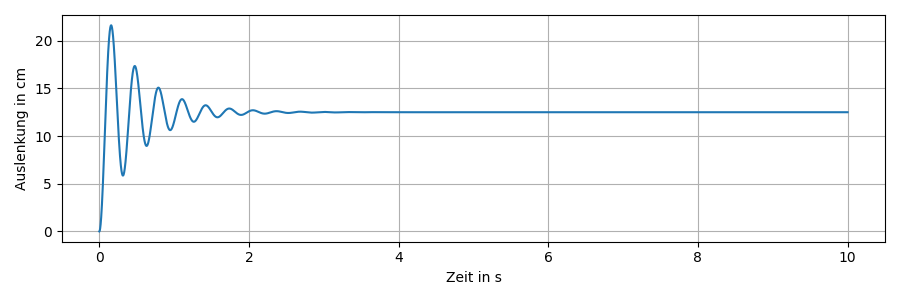

In [34]:
m = 2    # Masse (kg)
k = 800  # Federkonstante (N/m)
d = 8    # Dämpfungskonstante (N.s/m)
F0 = 100 #N

s = ctrl.tf("s")            # Laplace-Variable definieren
G = 1 / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

t = linspace(0, 10, 8000, endpoint=True) # Zeitachse für die Simulation
u = ones(t.shape) * F0                   # Eingabe (Kraft) als Einheitssprungfunktion
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Kraft) simulieren

figure(figsize=(9,3))
xlabel('Zeit in s');ylabel('Auslenkung in cm'); grid()
plot(t,y*100); tight_layout()

## Offene Aufgabe aus letzter Vorlseung- Anpassen der Simulation:
    
- Simulieren Sie einen Kraftsprung von 200N. Welche Zellen müssen Sie dafür erneut ausführen?
- Wie hoch ist die maximale Auslenkung?
- Welchen Einfluss hat die Anpassung auf die Frequenz mit der das System schwingt?

## Bode Diagramm

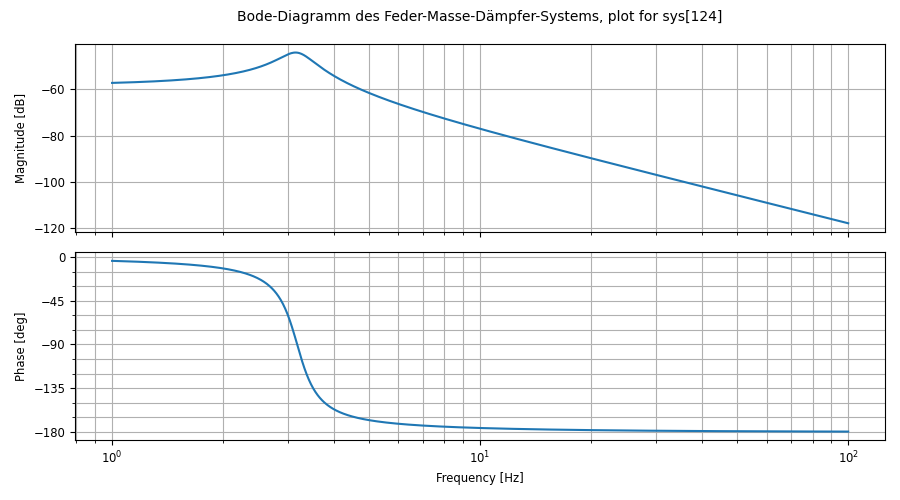

In [35]:
figure(figsize=(9, 5))
suptitle('Bode-Diagramm des Feder-Masse-Dämpfer-Systems')
_ = ctrl.bode_plot(G, dB=True, Hz=True)

## Berechnung der Eigenfrequenz des Systems

In [36]:
ctrl.damp(G)

eigenfrequencies, damping_ratios, poles = ctrl.damp(G, doprint=False)

    Eigenvalue (pole)       Damping     Frequency
        -2     +19.9j           0.1            20
        -2     -19.9j           0.1            20


In [37]:
sqrt(k/m) / (2*pi)

np.float64(3.183098861837907)

### Eigenfrequenz des Systems

$ω_0 = \sqrt{\frac{k}{m}}$

### Mit welchem Befehl kann die maximale Auslenkung ausgegeben werden?

In [6]:
max(y)

np.float64(0.2161537010439293)

### Wie können wir die Auslenkung im eingeschungenen Zustand ausgeben?

In [7]:
y[-1]

np.float64(0.1250000001448843)

### Zu welcher Zeit tritt die maximale Auslenkung auf?
Hinweis: ```np.argmax(...)```

In [8]:
t[argmax(y)]

np.float64(0.15751968996124516)

### Wie kann man die Auslenkung im eingeschwungenen Zustand anhand der Übertragungsfunktion bestimmen (Analytische Lösung)?
$G(s) = \frac{1}{k + s d + s^2 m}$

$y(s) = u(s)  G(s) = \frac{u(s)}{k + s d + s^2 m}$

$\begin{align}
u(t) = \begin{cases}
0 : & t < 0\\
F_0 : & t \geq 0
\end{cases}
\end{align}\qquad$
Wie lautet $u(s)$?

$u(s) = \frac{1}{s}F_0 \qquad$ und damit $\qquad y(s) = \frac{\frac{1}{s}F_0}{k+sd+s^2m}$

### Limit Satz für Lapalce Transformationen

**Anfangswert:**<br>
$y(t=0) = \lim\limits_{s\to\infty} s y(s)$<br>
**Endwert:**<br>
$y(t= \infty) = \lim\limits_{s\to0} s y(s)$

$y(s) = \frac{\frac{1}{s}F_0}{k+sd+s^2m}$, also ist der Enzustand?

$\lim\limits_{s\to0} \frac{\frac{s}{s}F_0}{k+sd+s^2m} = \frac{F_0}{k} = \frac{100\,\mathrm{N}}{800 \,\mathrm{N/m}} = 0.125 \mathrm{m} = 12.5 \mathrm{cm}$ <span style="color:green">✓</span>

**Frage:** Kann man ähnlich "einfach" zu einer Lösung für die maximale Auslekung kommen?

## Welchen Einfluss hat die Gewichtskraft auf die Bewegungsgleichung?

**Ansatz:** Einwirkende Kraft $u(t) = u_e(t) - F_g$, mit $F_g = mg$

Da es sich um ein linierares System handelt können wir rechnen:<br>
$y(s) = u(s)G(s) = u_e(s)G(s) - F_g(s)G(s) = y(s) + y_0(s)$

## Berechnung der Auslenkung durch die Gewichtskraft (Analytische Lösung)



$y_0 = -\mathcal{L}\{F_g\}G(s) = -\frac{\frac{1}{s}mg}{k + s d + s^2 m}$


**Erinnerung:** $\mathcal{L}\{f(t)\} = \int_{0}^{\infty} f(t) \mathrm e^{-st} \,\mathrm{d}t$ <br>
das bedeutet, die Laplace Transformation beginnt bei t=0. Ab wann wirkt die Gewichtskraft?

**Eingeschwungener Zustand:** $\lim\limits_{s\to0} s y_2(s)$ <br>
$y_0 = \lim\limits_{s\to0} -s\frac{\frac{1}{s}mg}{k + s d + s^2 m} = -\frac{mg}{k}  \approx - 2,5 cm$

## Berechnung der Auslenkung im eingeschwungenen Zustand (Simulative Lösung)

In [9]:
y0 = ctrl.dcgain(G) * (-m*10) # eingeschwungenede Ausleknung für die Gewichtskraft
y0

np.float64(-0.025)

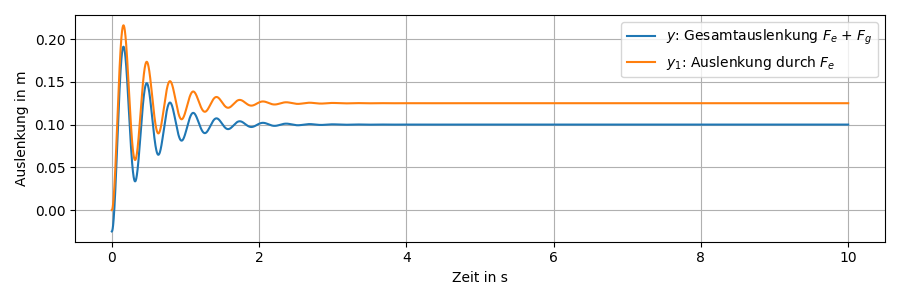

In [10]:
figure(figsize=(9,3))
xlabel('Zeit in s');ylabel('Auslenkung in m')
plot(t,y+y0, label='$y$: Gesamtauslenkung $F_e$ + $F_g$')
plot(t,y, label='$y_1$: Auslenkung durch $F_e$')
grid(); legend(); tight_layout()

## Berechnung der Auslenkung durch die Gewichtskraft (Anfangswert Lösung)

Bei der Laplace Transformation der Bewegungsgleichung haben wir streng genommen nicht die Anfangswerte berücksichtigt!

Mit der Ableitungsregel der Laplace Transformation,

$\mathcal{L}\{\dot y(t)\} = sy(s) - y_0$<br>
$\mathcal{L}\{\ddot y(t)\} = s^2y(s) - sy_0 - \dot y_0$

ergibt sich, <br>
$u = ky + d\dot y + m\ddot y$<br>
$u = ky + d(sy - y_0) + m (s^2y + sy_0 + \dot y_0)$

und so weiter ...

## Mit welcher Frequenz schwingt das gedämpfte System?
<b>Natürliche (ungedämpfte) Eigenfrequenz des Systems:</b> $ω_0 = \sqrt{\frac{k}{m}} = \sqrt{\frac{800}{2}} = 20 \,\mathrm{rad/s} \quad \implies T_0 = 0.314 \mathrm{s}\quad$<span style="color:orange">✓</span>

<b>Berechung des Dämpfungsgrads:</b>
$\zeta = \frac{d}{2\sqrt{km}} = \frac{8}{80} = 0.1$

<b>Frage:</b> Was sind Schwingfall, aperiodischer Grenzfall und Kriechfall?

<b>Gedämpfte Eigenfrequenz: </b> $\omega_d = \omega_0 \sqrt{1 - \zeta^2}$

$\omega_d = \omega_0 \sqrt{0.99} \approx 0.98 \omega_0  \quad \implies T_0 \approx 0.32 \mathrm{s}\quad$<span style="color:green">✓</span>

## 1. Aufgabe:

### Mit welcher Eigenfrequenz schwingt das System für $d=8 \cdot 4=32$?

<center> 
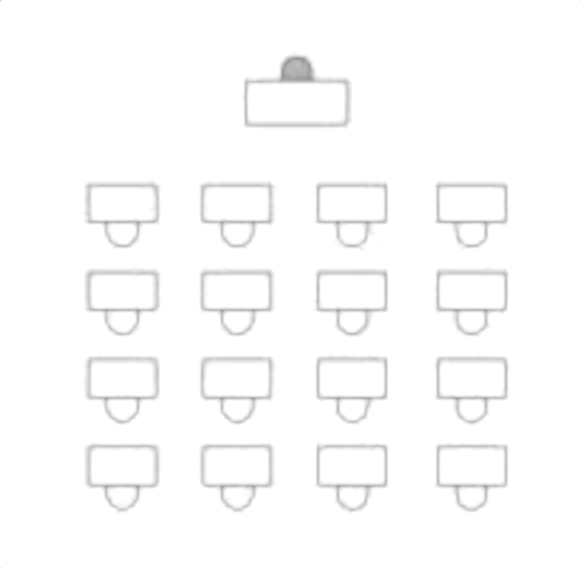
</center>
<center>Linke Seite: analytisch | Rechte Seite: simulativ </center>

## 1. Aufgabe (Lösung):



Wert aus der Simulation (abgelesen): T=0.342 s -> f=2.92 Hz

Wert aus der Berechnung: 

In [11]:
(20/(2*pi))*sqrt(1-0.4**2)

np.float64(2.917358295779998)

### 1. Aufgabe Visualisierung

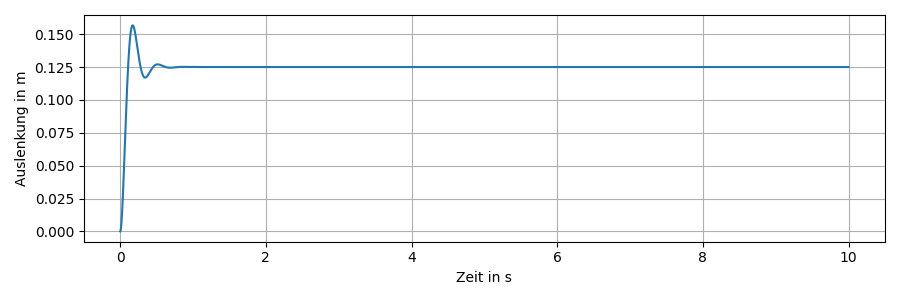

In [12]:
d = 32    # Dämpfungskonstante (N.s/m)

s = ctrl.tf("s")            # Laplace-Variable definieren
G = 1 / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Kraft) simulieren

figure(figsize=(9,3))
xlabel('Zeit in s');ylabel('Auslenkung in m'); grid()
plot(t,y); tight_layout()

## 1. Aufgabe (alternative Lösung):



In [13]:
_ = ctrl.damp(G, doprint=True)

    Eigenvalue (pole)       Damping     Frequency
        -8    +18.33j           0.4            20
        -8    -18.33j           0.4            20


### Wie war das nochmal mit den Eigenwerten?

$ y = C_a e^{(-8 + 18.33j) t} + C_b e^{(-8 - 18.33j) t} \quad$ Linearkombination aller möglichen Lösungen zur DGL

$y = e^{-8t} \cdot (C_1 \cos(18.33t) + C_2 \sin(18.33t))$

<b>Alternative Darstellung:</b> Dämpung * Schwingung <br>
mit Frequenz definiert durch Imaginärteil $\implies T = 0.343\,\mathrm{s}$

## Visualisierung / Beweis

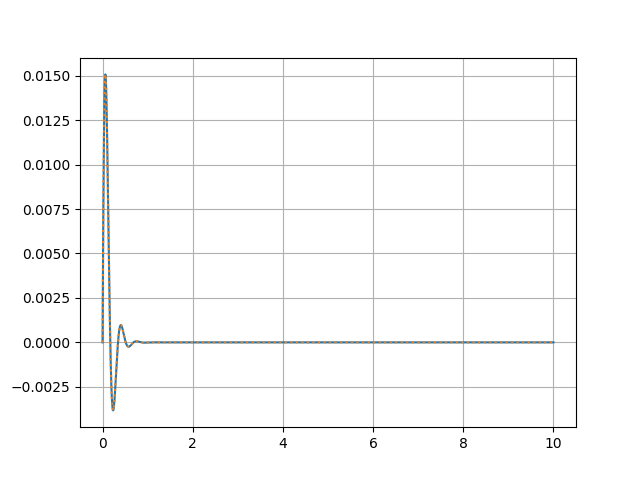

In [14]:
_, ya = ctrl.impulse_response(G,t)
yb    = e**(-8*t) * sin(18.33*t) * sqrt(21)/168 # C1= 0, C2 = sqrt(21)/168 = w0/(k*sqrt(1-zeta**2))

figure()
plot(t,ya); plot(t,yb, ':')
grid()

## 2. Aufgabe:

### Wie groß ist die Verstärkung bei der gedämpften Eigenfrequenz (18.33 rad/s)?

<center> 
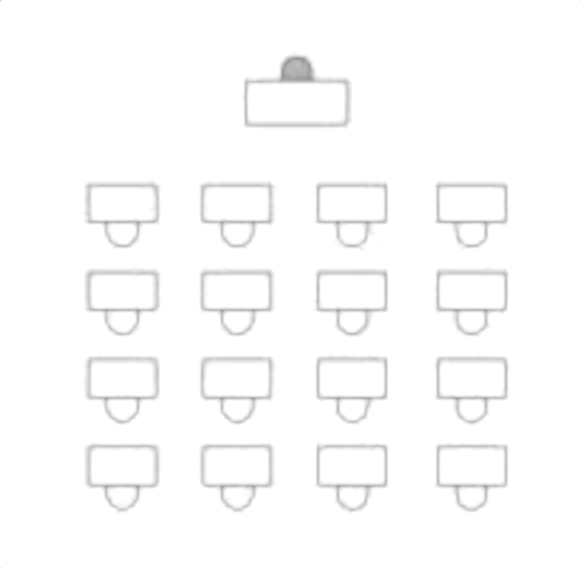
</center>
<center>Linke Seite: simulativ | Rechte Seite: analytisch </center>

## 2. Aufgabe (Lösung):



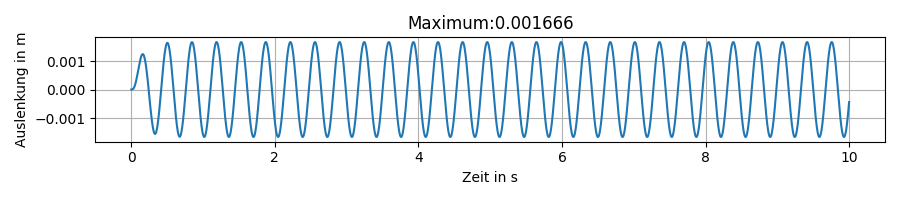

In [15]:
u = sin(18.33*t)                          # Eingabe (Kraft) als sinus
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Kraft) simulieren
figure(figsize=(9,2))
title(f'Maximum:{max(y):2.6f}'); xlabel('Zeit in s'); ylabel('Auslenkung in m'); grid()
plot(t,y); tight_layout()

### oder

In [16]:
mag, phase, _ = G.frequency_response([18.33])
mag

array([0.00166564])

### oder analytisch

In [17]:
# Ersetzung von s durch jw in der Übertragungsfunktion und Berechnung des Betrags (abs)
si = 1j* 18.33
abs(1 / (k + si*d + si**2 *m))

0.001665643726581416

### 3. Aufgabe: Bei welcher Frequenz ist die Verstärkung maximal (Resonanzfrequenz)?
Methode nach freier Wahl

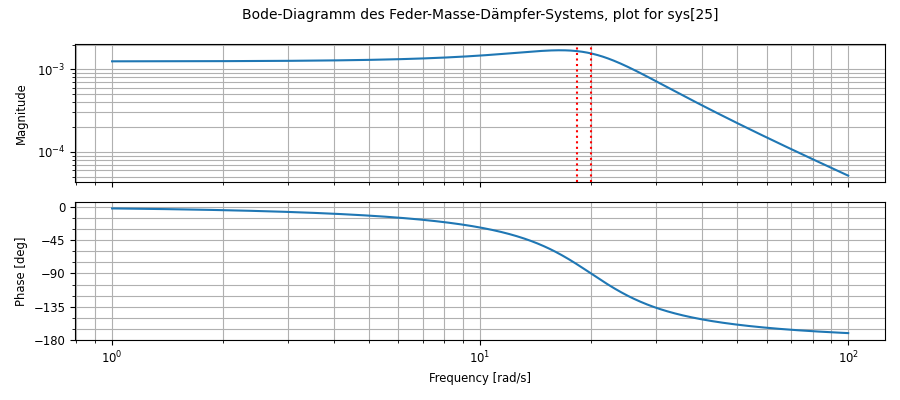

In [18]:
figure(figsize=(9, 4)); suptitle('Bode-Diagramm des Feder-Masse-Dämpfer-Systems')
_ = ctrl.bode_plot(G, Hz=False, dB=False)
subplot(211); axvline(18.33333, ls=':', c='r'); axvline(20, ls=':', c='r')

## 3. Aufgabe (Lösung):



$\omega_{\text{res}} = \omega_0 \sqrt{1 - 2D^2}$

In [19]:
D = d/(2*sqrt(m*k))
w0 = sqrt(k/m)
wr = w0 * sqrt(1-2*D**2)
wr

np.float64(16.49242250247064)

In [20]:
mag, phase, _ = G.frequency_response([wr, 18, 18.33, 20])
mag

array([0.00170483, 0.00167865, 0.00166564, 0.0015625 ])

## 2. Übung - Erweiterung des Modells
- Wie muss das Modell angepasst werden, damit nicht eine Kraft sondern eine Auslenkung des Rades vorgegeben wird?

- Hinweise:
    - Die Auslekung ist das Geländeprofil im Querschnitt. Der Einfluss des Raddurchmessers kann vernachlässigt werden
    - Das Rad soll sich mit konstanter Geschwindigkeit horizontal bewegen
    - Wir betrachten den vereinfachten Fall eines "Einrades"
    - Die Masse kann konzentriert über dem Rad angenommen werden
    


### Aufstellung der Bewegungsgleichung



$F_k + F_d + F_m = 0$ 

$k(u-y) + d(\dot{u} -\dot{y}) -\ddot{y}m = 0$

### Übertragungsfunktion

$G(s) = \frac{y}{u} = \frac{sd + k}{s^2m + sd +k}$

<b>Frage:</b> Was können wir an der Übertragunsfunktion ablesen?

In [21]:
G.dcgain() # oder s=0 setzen und kürzen

np.float64(0.00125)

## 1. Aufgabe:

### Nehmen Sie das Notebook aus Übung 1 als Basis und passen Sie die Übertragungsfunktion an

$G(s) = \frac{y}{u} = \frac{sd + k}{s^2m + sd +k}$

### 1. Aufgabe (Lösung)

In [22]:
m = 2    # Masse (kg)
k = 800  # Federkonstante (N/m)
d = 8    # Dämpfungskonstante (N.s/m)

s = ctrl.tf("s")            # Laplace-Variable definieren
G = (s*d+k) / (k + s*d + s**2 *m) # Feder-Masse-Dämpfer-Übertragungsfunktion

### Aufgabe 2: Erzeugen Sie einen Eingang u, der das folgende Geländeprofil abbildet

0 m bis 1 m: gerade bei 0 cm<br>
1 m bis 2 m: konstant ansteigend von 0 cm auf 30 cm <br>
2 m bis 10 m: sprunghaft von 3 cm auf 0 cm und gerade weiter<br>
Bewegung mit konstanter Geschwindigkeit $v_0 = 30\,\mathrm{km/h}$



    dt = 0.0001
    v = 30/3.6
    N = int(1/(dt*v)) # Werte pro Meter
    u = hstack([
        zeros(N),                         # 1. Abschnitt (Gerade)
        ??????,                           # 2.Abschnitt (Rampe)
        ??????                            # 3.Abschnitt
    ])


### 2. Aufgabe (Lösung)

In [23]:
dt = 0.0001
v = 30/3.6      # 30 km/h
N = int(1/(dt*v)) # Werte pro Meter
u = hstack([
    zeros(N),                         # 1. Abschnitt (Gerade)
    linspace(0,0.3,N),                # 2.Abschnitt (Rampe)
    zeros(8*N)                        # 3.Abschnitt
])
t = arange(len(u))*dt

### Plot des Eingangs

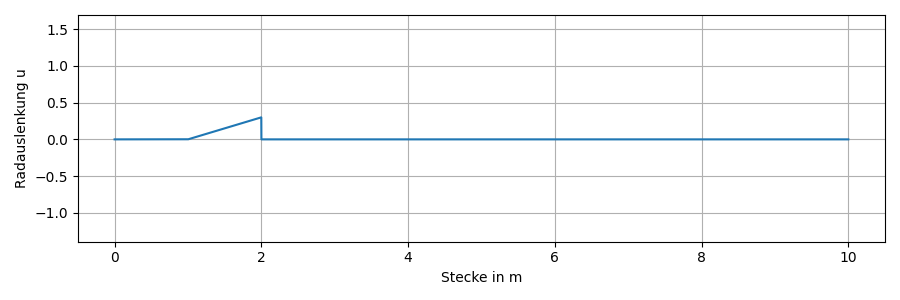

In [24]:
figure(figsize=(9,3))
plot(t*v,u)
xlabel('Stecke in m'); ylabel('Radauslenkung u')
axis('equal'); tight_layout(); grid()

### Aufgabe 3: Führen Sie die Simulation aus und visualisieren Sie das Ergebniss

### 3. Aufgabe (Lösung)

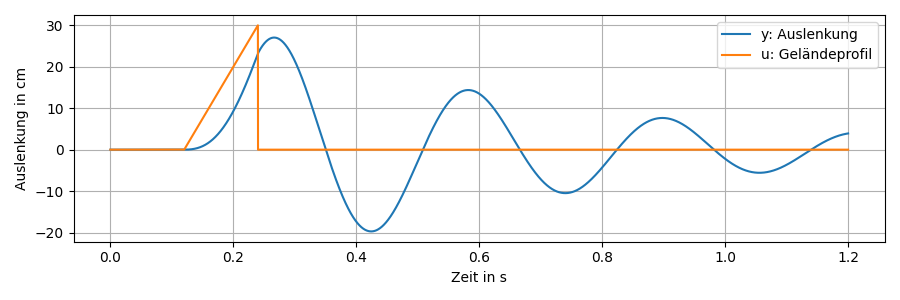

In [25]:
t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Auslenkung) simulieren

figure(figsize=(9,3))
xlabel('Zeit in s');ylabel('Auslenkung in cm');
plot(t,y*100, label='y: Auslenkung');
plot(t,u*100, label='u: Geländeprofil');
legend();grid();tight_layout()

### Aufgabe 4:  Erstellen Sie das Bodediagram

### Lösung Aufgabe 4

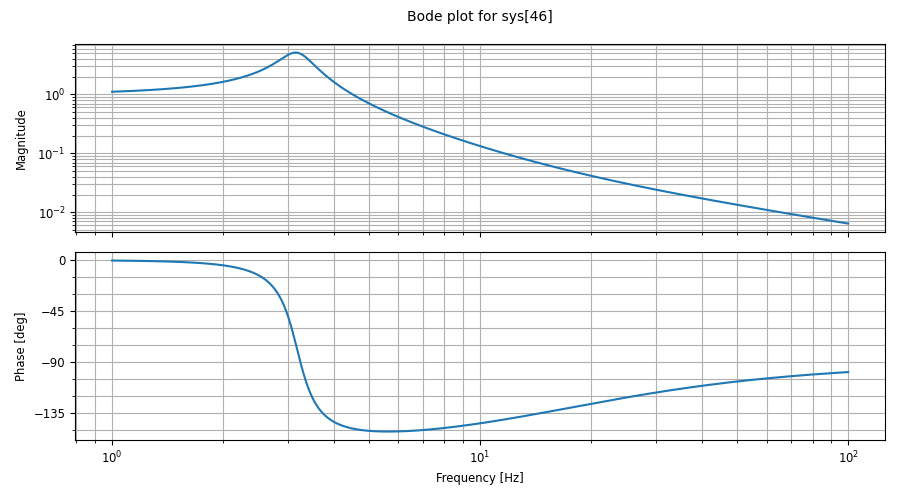

In [26]:
fig = figure(figsize=(9, 5))
_ = ctrl.bode_plot(G, dB=False, Hz=True)

### Aufgabe 5: Auslegung der Federung

Der Dämpfungsgrad $D$ eines mechanischen Feder-Masse-Dämpfer Systems ist gegeben durch: <br>
$D = \frac{d}{2 \sqrt{m\cdot k}} \ = \frac{d \omega_n}{2k} \ = \frac{d }{2m \omega_n}$<br>
mit $\omega_n=\sqrt {\frac {k}{m}}$
    
- Nemen Sie die Masse als gegeben an mit 2 kg
- Legen Sie das System auf eine natürliche Resoanzfrequenz von 1 Hz aus
- Untersuchen Sie das Systemverhalten für $D=0.2$ (1. Reihe), $D=0.5$ (2. Reihe), $D=1.0$ (3. Reihe) und $D=1.5$ (4. Reihe)

> Typische Werte für Straßenfahrzeuge:<br>
> natürliche Resoanzfrequenz  $\omega_n  \approx 1\,\mathrm{Hz}$ <br>
> Dämpfungsgrad $0.2 < D < 0.4$
> <small>Fundamentals of vehicle dynamics: Thomas D. Gillespie, 2021</small>

In [27]:
print("D :", d/(2*sqrt(m*k)))
print("fn:",sqrt(k/m), "Hz")

D : 0.1
fn: 20.0 Hz


## Auslegung für $D$ und $w_0$

In [28]:
Ga = []
Da = [1.5, 1, 0.5, 0.2]
for Di in Da:
    m =  2     #kg
    w0 = 2*pi *1
    D =  Di
    k =  w0**2 * m
    d =  D*2*sqrt(m*k)

    Ga +=[(s*d+k) / (k + s*d + s**2 *m)] # Feder-Masse-Dämpfer-Übertragungsfunktion
    
    print('--------------')
    print(f"Für {Di:2.1f}:")
    print(f"d: {d:4.2f} N/m")
    print(f"k: {k:4.2f}")

--------------
Für 1.5:
d: 37.70 N/m
k: 78.96
--------------
Für 1.0:
d: 25.13 N/m
k: 78.96
--------------
Für 0.5:
d: 12.57 N/m
k: 78.96
--------------
Für 0.2:
d: 5.03 N/m
k: 78.96


### Visualisierung

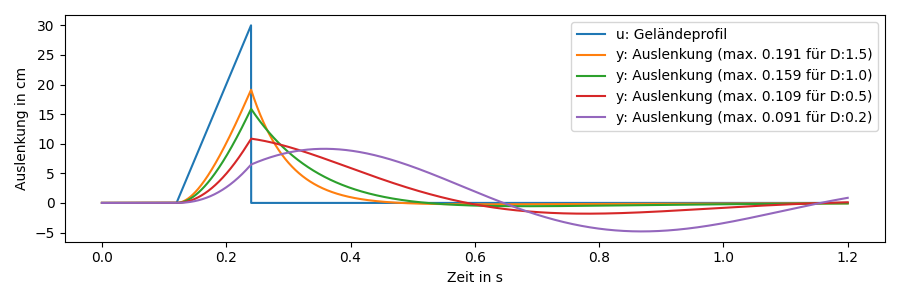

In [29]:
figure(figsize=(9,3))
plot(t,u*100, label='u: Geländeprofil')
for Di,G in zip(Da,Ga):
    t, y = ctrl.forced_response(G, t, u)     # Systemantwort auf die Eingabe (Kraft) simulieren
    xlabel('Zeit in s');ylabel('Auslenkung in cm')
    plot(t,y*100, label=f'y: Auslenkung (max. {max(y):4.3f} für D:{Di:2.1f})')

    legend();grid();tight_layout()

### Aufgabe 6: Wie groß ist die Beschleunigung der Masse
**Hinweis:** ```np.diff``` oder ```np.gradient```

### 6. Aufgabe (Lösung)

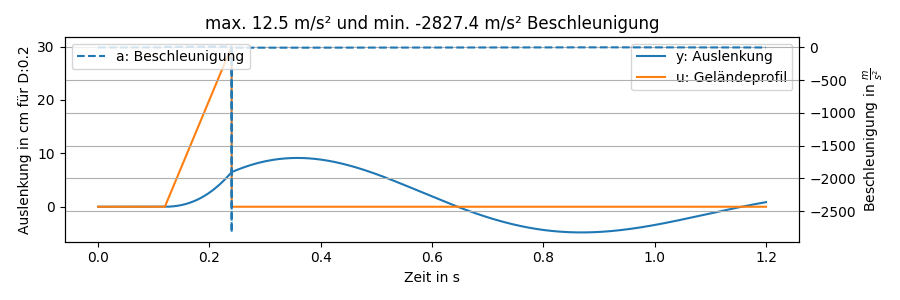

In [30]:
v = gradient(y,dt)
a = gradient(v,dt)

figure(figsize=(9,3)); title(f'max. {max(a):2.1f} m/s² und min. {min(a):2.1f} m/s² Beschleunigung')
xlabel('Zeit in s');ylabel(f'Auslenkung in cm für D:{D:2.1f}')
plot(t,y*100, label='y: Auslenkung')
plot(t,u*100, label='u: Geländeprofil')
legend(loc=0);twinx()
plot(t,a, '--', label='a: Beschleunigung')
ylabel('Beschleunigung in $\\frac{m}{s^2}$'); legend(loc=2);grid();tight_layout()

### Welches Problem besteht bei der min. Beschleunigung?

In [31]:
!jupyter nbconvert "Vorlesung 2 - Simulation mechanischer Systeme.ipynb" --to slides
# Kann mit Firefox als PDF gedruckt werden

[NbConvertApp] Converting notebook Vorlesung 2 - Simulation mechanischer Systeme.ipynb to slides
[NbConvertApp] WARNING | Alternative text is missing on 14 image(s).
[NbConvertApp] Writing 1134134 bytes to Vorlesung 2 - Simulation mechanischer Systeme.slides.html
